# ML Classification

## Regression

**Goal**: Assign input data to specific, predefined labels or categories.

**Types**: 
1. Binary - Two choices (e.g., pass/fail, email as spam or not).
2. Multiclass: More than two choices (e.g., cat, dog, or bird).

**Common Algorithms**: Logistic Regression, Decision Trees, Support Vector Machines (SVM), Random Forests, K-Nearest Neighbors (KNN), Naive Bayes.

**Real-World Examples**:
1. Detecting whether a bank transaction is fraudulent or safe.
2. Diagnosing if a medical test is positive or negative for a disease.

## Types of Classification

1. Linear Regression - Is used when dependent variable is categorical.
2. Decision Tree -
    3. Graphical Representation of all the possible solution to a decision
    4. Decision are based on some conditions
    5. Decision can be easily explained
6. Random Forest - builds and merges multiple decision trees to get more accurate and stable output.
    7. Random because each decision tree contains random subset of feature when forming question and they have only access to random sample sets
    8. Constructing flow chart of questions
    9. Wisdom of random and diverse crowd
    10. Training is done is using bagging method - building multiple decision tree from random sample set
8. K-nearest neighbour - use and classify new data points based on similarity measures
    9. K in KNN is the nearest neighbour we wish to take sample or vote from
    10. Non parametric (does not make any assumption), lazy algorithm (does not use training data points for generalization or phase) but most used algorithm
    11. To use a database where data points are separated
10. Naive Byes - Completely based Bayes Theorem
    11. We can find prob happening of A based given that B has already occurred
    12. Features are independent , it does not affect others

### Decision Tree

### Terminology

- **Root Node** - Entire Dataset, homogenous dataset
- **Leaf Node** - Node which can not be segregate to further node
- **Splitting** - Dividing the root or sub nodes further based on some conditions
- **Branch / Sub Tree** - Formed by splitting the node
- **Pruning** - Removing unwanted branches from the tree
- **Parent Node** - Root node
- **Child Node** - Any other node
- If **Gini Impurity** = 0, It's **pure value**
- Else, It's **mixed value**

### Details

- How do we choose best attribute for the decision tree ? OR How does a tree decides on how to split ?
- Entropy -
    - Defines the randomness in the data
    - It is a metric which measures the impurity
    - It is a first step to solve the problem
- Information Gain -
    - It is a decrease in entropy after a dataset is split on the basis of an attribute
    - Constructing a decision tree is all about finding attribute that returns highest gain.
- Gini Index - For checking the purity/impurity of dataset
- Reduction in Variance -
    - Algorithm used for continous target variables (regression problem).
    - Split with lower variance is selected as criteria to split the population



#### Calculation of Entropy

** Entropy(s) = - P(yes)log2P(yes) - P(no)log2P(no)**
** Information Gain IG = Entropy(S) - [(Weighted AVG) *E(Each Feature)]**
--
Where,
- S - is the total sample space
- P(yes) - Probability of yes
- If Probability of yes = Probability of no, then Entropy = P(S) = 0.5
    - Entropy(S) = 1
- If it contains all Probability of yes or Probability of no, then P(S) = 1 or 0
    - Entropy(S) = 0

**Exmaple:**
- Suppose there are 9 Yes and 5 No, total = 5/14
- So E(S) = - P(9/14)*log2P(9/14) - P(5/14)*log2P(5/14)
- E(S) = 0.41+0.53 = 0.94

- Entropy of each feature
- Sunny - -(2/5)*log2(2/5) - 3/5log2(3/5) = 0.971
- Overcast - -1 *log2 (1 - 0) - 0 log2 0 = 0
- Rainy - -(3/5)*log2(3/5) - 2/5log2(2/5) = 0.971
- Information Gain on Weath: **IG =  0.94 - [5/14*0.971 + 4/14*0+ 5/14*0.971] = 0.940 - 0.693 = 0.247**

### Decision Tree Regressor

np.float64(7.4374442748869)

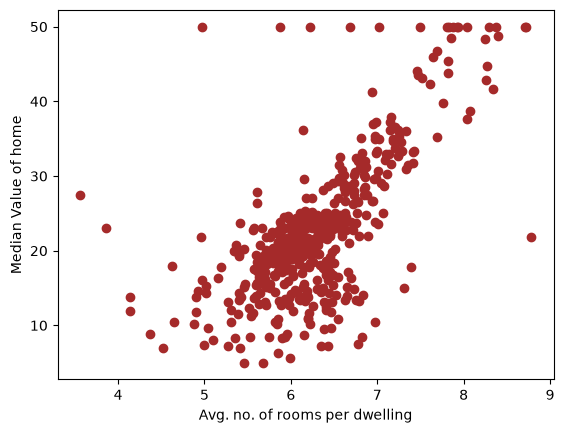

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#boston_dataset
boston = pd.read_csv("./datasets/boston.csv")
boston.head()

#plot the chart
plt.scatter(x=boston['rm'], y=boston['medv'], color='brown')
plt.xlabel('Avg. no. of rooms per dwelling')
plt.ylabel('Median Value of home')
# as avg no of rooms increase median price of homes also increase
# indirectly size of room will increase too

x = pd.DataFrame(boston['rm']) # features or independent variable
y = pd.DataFrame(boston['medv']) # target

# splitting into train and test

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20) # 20% records in test, 80% in training

from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(x_train, y_train)

# predicting the value
y_pred = regressor.predict(x_test)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_pred, y_test)
rmse = np.sqrt(mse)
rmse